In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shauryaraj111","key":"1905f2e665873f08fb996092f2dd1619"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list -s euvp

ref                                                              title                                          size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  ---------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
pamuduranasinghe/euvp-dataset                                    EUVP dataset                             1225498118  2023-08-02 01:45:30.323000           3962         17  0.8125           
projectbatch000/euvp-dataset                                     EUVP DATASET                             1226069431  2021-11-26 07:54:26.760000            255          4  0.25             
littlepinkversion/uieb-euvp                                      UIEB-EUVP                                4305716311  2023-04-19 14:41:14.570000            109          2  0.25             
dishitagoyal/euvp-dataset                         

In [5]:
!kaggle datasets download -d pamuduranasinghe/euvp-dataset

Dataset URL: https://www.kaggle.com/datasets/pamuduranasinghe/euvp-dataset
License(s): CC0-1.0
100% 1.14G/1.14G [00:11<00:00, 109MB/s] 



In [6]:
!unzip -q euvp-dataset.zip -d EUVP

In [7]:
!pip install torch torchvision pillow matplotlib tqdm

In [8]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [9]:
class EUVPDataset(Dataset):

    def __init__(self, input_dir, target_dir, transform=None):

        self.input_dir = input_dir
        self.target_dir = target_dir
        self.transform = transform

        self.images = sorted(os.listdir(input_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        input_path = os.path.join(
            self.input_dir,
            self.images[idx]
        )

        target_path = os.path.join(
            self.target_dir,
            self.images[idx]
        )

        input_image = Image.open(input_path).convert("RGB")
        target_image = Image.open(target_path).convert("RGB")

        if self.transform:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)

        return input_image, target_image

In [10]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [15]:
trainA = "/content/EUVP/trainA"
trainB = "/content/EUVP/trainB"

In [17]:
!find /content/EUVP -type d

/content/EUVP
/content/EUVP/EUVP
/content/EUVP/EUVP/Unpaired
/content/EUVP/EUVP/Unpaired/trainB
/content/EUVP/EUVP/Unpaired/trainA
/content/EUVP/EUVP/Unpaired/validation
/content/EUVP/EUVP/eval_data
/content/EUVP/EUVP/eval_data/ufo_test
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan-up
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan-up/funie-gan-up
/content/EUVP/EUVP/eval_data/ufo_test/deep-sesr
/content/EUVP/EUVP/eval_data/ufo_test/deep-sesr/deep-sesr
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan/funie-gan
/content/EUVP/EUVP/eval_data/ufo_test/ugan
/content/EUVP/EUVP/eval_data/ufo_test/ugan/ugan
/content/EUVP/EUVP/eval_data/ufo_test/ugan-p
/content/EUVP/EUVP/eval_data/ufo_test/ugan-p/ugan-p
/content/EUVP/EUVP/eval_data/euvp_test
/content/EUVP/EUVP/eval_data/euvp_test/funie-gan-up
/content/EUVP/EUVP/eval_data/euvp_test/funie-gan-up/funie-gan-up
/content/EUVP/EUVP/eval_data/euvp_test/deep-sesr
/content/EUVP/EUVP/eval_data/euvp_test/deep

In [18]:
!find /content/EUVP -type d | head -100

/content/EUVP
/content/EUVP/EUVP
/content/EUVP/EUVP/Unpaired
/content/EUVP/EUVP/Unpaired/trainB
/content/EUVP/EUVP/Unpaired/trainA
/content/EUVP/EUVP/Unpaired/validation
/content/EUVP/EUVP/eval_data
/content/EUVP/EUVP/eval_data/ufo_test
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan-up
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan-up/funie-gan-up
/content/EUVP/EUVP/eval_data/ufo_test/deep-sesr
/content/EUVP/EUVP/eval_data/ufo_test/deep-sesr/deep-sesr
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan
/content/EUVP/EUVP/eval_data/ufo_test/funie-gan/funie-gan
/content/EUVP/EUVP/eval_data/ufo_test/ugan
/content/EUVP/EUVP/eval_data/ufo_test/ugan/ugan
/content/EUVP/EUVP/eval_data/ufo_test/ugan-p
/content/EUVP/EUVP/eval_data/ufo_test/ugan-p/ugan-p
/content/EUVP/EUVP/eval_data/euvp_test
/content/EUVP/EUVP/eval_data/euvp_test/funie-gan-up
/content/EUVP/EUVP/eval_data/euvp_test/funie-gan-up/funie-gan-up
/content/EUVP/EUVP/eval_data/euvp_test/deep-sesr
/content/EUVP/EUVP/eval_data/euvp_test/deep

In [19]:
!ls /content/EUVP

EUVP


In [20]:
trainA = "/content/EUVP/EUVP/Paired/underwater_imagenet/trainA"
trainB = "/content/EUVP/EUVP/Paired/underwater_imagenet/trainB"

In [21]:
dataset = EUVPDataset(
    trainA,
    trainB,
    transform=transform
)

print("Dataset Loaded Successfully")
print("Total Images:", len(dataset))

Dataset Loaded Successfully
Total Images: 3700


In [22]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print("DataLoader Created Successfully")

DataLoader Created Successfully


In [23]:
x, y = dataset[0]

print(x.shape)
print(y.shape)

torch.Size([3, 256, 256])
torch.Size([3, 256, 256])


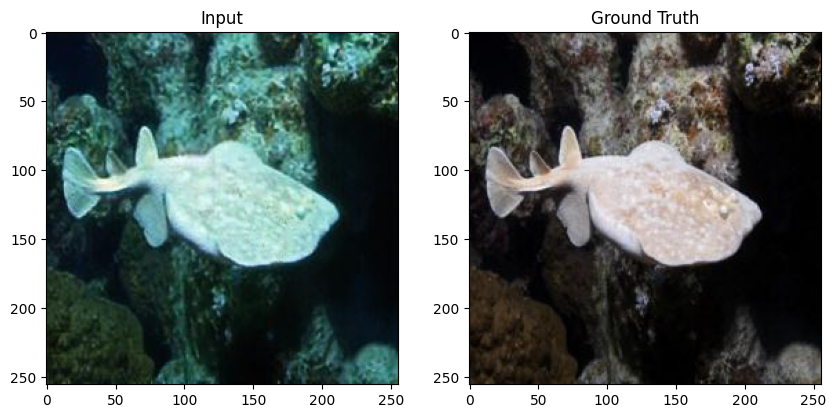

In [24]:
import matplotlib.pyplot as plt

img1,img2 = dataset[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1.permute(1,2,0))
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(img2.permute(1,2,0))
plt.title("Ground Truth")

plt.show()

In [25]:
import torch.nn as nn

class SimpleUNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,3,1)
        )

    def forward(self,x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [26]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SimpleUNet().to(device)

print(model)

SimpleUNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [27]:
sample = torch.randn(
    1,
    3,
    256,
    256
).to(device)

output = model(sample)

print(output.shape)

torch.Size([1, 3, 256, 256])


In [28]:
criterion = nn.L1Loss()

In [29]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [30]:
epochs = 3

for epoch in range(epochs):

    total_loss = 0

    for inputs, targets in loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)

        loss = criterion(
            outputs,
            targets
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}"
    )

Epoch 1 Loss: 0.0672
Epoch 2 Loss: 0.0574
Epoch 3 Loss: 0.0564


In [31]:
torch.save(
    model.state_dict(),
    "unet_euvp.pth"
)

print("Model Saved")

Model Saved


In [33]:
from google.colab import files

files.download(
    "unet_euvp.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

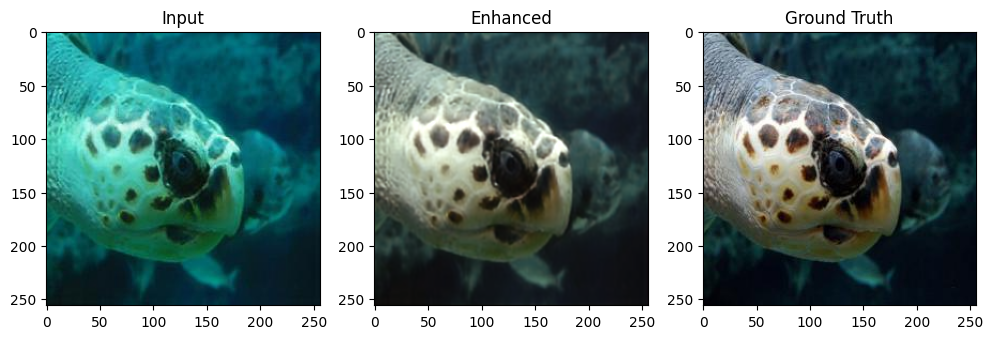

In [34]:
inputs,targets = next(iter(loader))

inputs = inputs.to(device)

with torch.no_grad():
    outputs = model(inputs)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(inputs[0].cpu().permute(1,2,0))
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(outputs[0].cpu().permute(1,2,0))
plt.title("Enhanced")

plt.subplot(1,3,3)
plt.imshow(targets[0].permute(1,2,0))
plt.title("Ground Truth")

plt.show()

In [35]:
import torch
import math

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2)

    if mse == 0:
        return 100

    psnr = 20 * math.log10(1.0 / math.sqrt(mse))
    return psnr

inputs, targets = next(iter(loader))

inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
    outputs = model(inputs)

psnr = calculate_psnr(outputs, targets)

print("PSNR Score:", psnr)

PSNR Score: 22.602216108228788


In [36]:
from google.colab import files
uploaded = files.upload()

Saving test_img.jpeg to test_img.jpeg


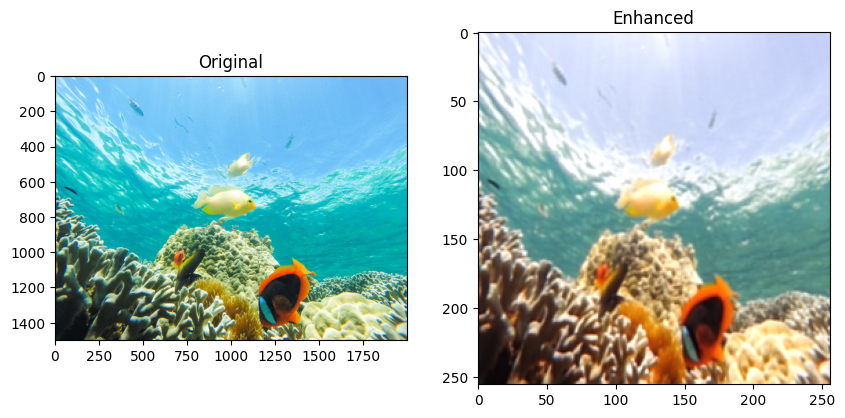

In [37]:
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")

input_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(output[0].cpu().permute(1,2,0).clamp(0,1))
plt.title("Enhanced")

plt.show()

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
